# **Import Library**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Preparation**

### Import Dataset


In [ ]:
df = pd.read_csv('/content/Bank_Loan_Default_dataset.csv')
display(df)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


### Data Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


⚠️ Missing Values

The data has 146 missing values in several columns, with details as below.

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# Hitung jumlah baris yang duplikat
jumlah_duplikat = df.duplicated().sum()
print(jumlah_duplikat)

0


In [ ]:
# Cek tipe data
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


### Data Cleaning

In [ ]:
# Mengubah tipe data 'Credit_History' Lebih baik diubah ke int64 supaya lebih konsisten.
df['Credit_History'] = df['Credit_History'].astype('Int64')  # pakai 'Int64' agar bisa handle NaN juga
# Mengubah tipe data 'Loan_Amount_Term' Karena ini sebenarnya "jumlah bulan" (angka bulat), lebih baik diubah jadi integer.
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype('Int64')  # pakai Int64 untuk NaN support

Replace null values ​​in **Gender, Married, Dependents, Self_Employed** columns with mode(most frequent), because categorical values ​​are not suitable for use with mean/median.

In [ ]:
# Imputasi Kategorikal
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

Replace null values ​​in the **LoanAmount** column with the median. Avoid outliers affecting the imputation results.

In [ ]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

Replace null values ​​in the **Loan_Amount_Term** column with mode. Because generally the standard terms are similar.

Replace null values ​​in the **Credit_History** column with mode. Because it is 0/1 like the category.

In [ ]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [ ]:
# Ubah Vales 'Y' jadi 'Yes' dan 'N' jadi 'No'
df['Loan_Status'] = df['Loan_Status'].replace({'Y': 'Yes', 'N': 'No'})

Final Check

In [ ]:
display(df)
df.info()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Yes
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,No
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Yes
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Yes
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360,1,Rural,Yes
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180,1,Rural,Yes
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360,1,Urban,Yes
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360,1,Urban,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    Int64  
 10  Credit_History     614 non-null    Int64  
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: Int64(2), float64(2), int64(1), object(8)
memory usage: 63.7+ KB


### Summarize data

Descriptive statistics for numerical data

In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.0,614.0
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.0,0.0
25%,2877.500000,0.000000,100.250000,360.0,1.0
50%,3812.500000,1188.500000,128.000000,360.0,1.0
75%,5795.000000,2297.250000,164.750000,360.0,1.0
max,81000.000000,41667.000000,700.000000,480.0,1.0


Descriptive statistics for non-numerical data

In [ ]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,614,614,614,614,614,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Yes
freq,1,502,401,360,480,532,233,422


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,502
Female,112


In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Yes,422
No,192


### Export Data

In [ ]:
df.to_csv('Bank_Loan_Default_dataset_clean.csv', index=False)

# **Exploratory Data Analysis**

Bivariate Analysis

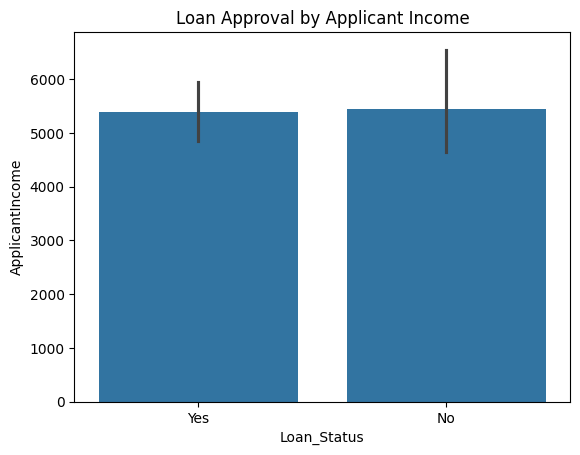

In [ ]:
sns.barplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Loan Approval by Applicant Income')
plt.show()

Pearson correlation analysis for numeric columns

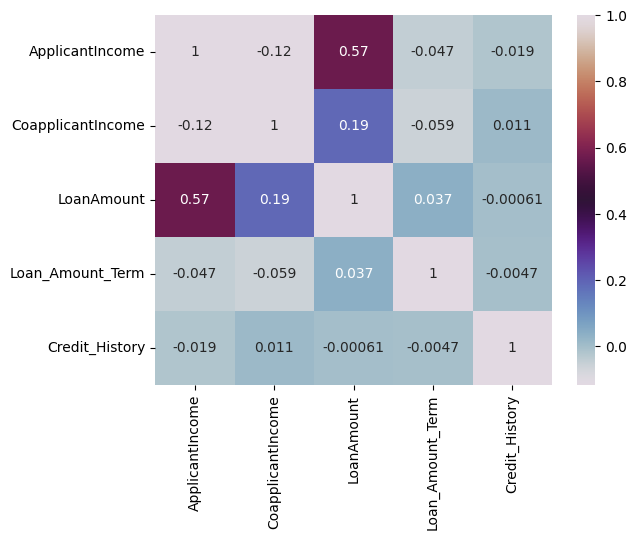

In [ ]:
heatmap = sns.heatmap(df.corr(numeric_only=True, method='pearson'),
                      annot=True, cmap='twilight')
plt.show()

Correlation Matrix


In [ ]:
# Calculate correlation only for numeric columns
df.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000


from matplotlib import pyplot as plt
_df_0['ApplicantIncome'].plot(kind='hist', bins=20, title='ApplicantIncome')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['CoapplicantIncome'].plot(kind='hist', bins=20, title='CoapplicantIncome')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['LoanAmount'].plot(kind='hist', bins=20, title='LoanAmount')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Loan_Amount_Term'].plot(kind='hist', bins=20, title='Loan_Amount_Term')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='Loan_Amount_Term', y='Credit_History', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['ApplicantIncome'].plot(kind='line', figsize=(8, 4), title='ApplicantIncome')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['CoapplicantIncome'].plot(kind='line', figsize=(8, 4), title='CoapplicantIncome')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['LoanAmount'].plot(kind='line', figsize=(8, 4), title='LoanAmount')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['Loan_Amount_Term'].plot(kind='line', figsize=(8, 4), title='Loan_Amount_Term')
plt.gca().spines[['top', 'right']].set_visible(False)